# Ejemplos de graficos con Matplotlib y pandas

Este notebook presenta varios graficos comunes usando datos sinteticos. Todas las celdas son reproducibles y no requieren archivos externos.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(42)

meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
ventas = np.array([18, 21, 19, 24, 28, 31, 29, 35, 33, 38, 42, 47])
df = pd.DataFrame({"mes": meses, "ventas": ventas})
df.head()

,mes,ventas
0,Ene,18
1,Feb,21
2,Mar,19
3,Abr,24
4,May,28


## 1. Grafico de lineas

Es util para observar tendencias o cambios a lo largo del tiempo.

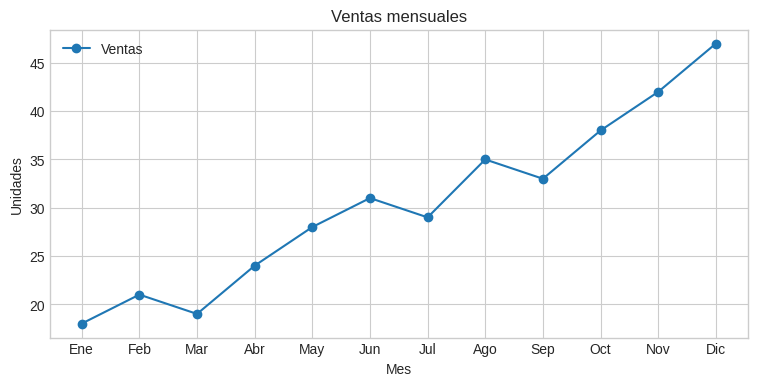

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df["mes"], df["ventas"], marker="o", color="tab:blue", label="Ventas")
ax.set(title="Ventas mensuales", xlabel="Mes", ylabel="Unidades")
ax.legend()
plt.show()

## 2. Grafico de barras

Permite comparar cantidades entre categorias.

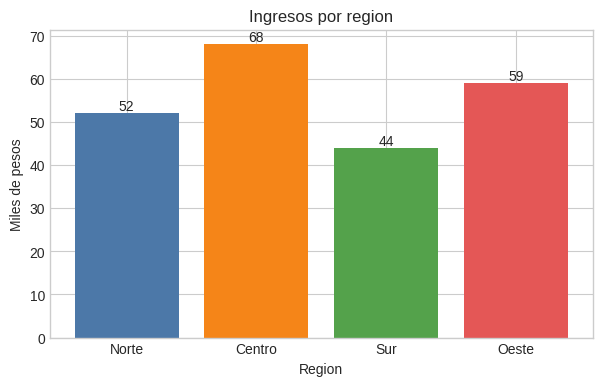

In [13]:
categorias = ["Norte", "Centro", "Sur", "Oeste"]
ingresos = [52, 68, 44, 59]

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(categorias, ingresos, color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])
ax.bar_label(barras, fmt="%d")
ax.set(title="Ingresos por region", xlabel="Region", ylabel="Miles de pesos")
plt.show()

## 3. Histograma

Muestra la distribucion de una variable numerica.

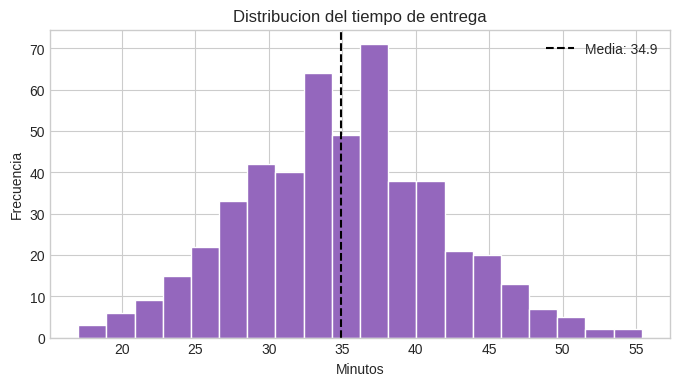

In [14]:
tiempos = rng.normal(loc=35, scale=7, size=500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(tiempos, bins=20, color="tab:purple", edgecolor="white")
ax.axvline(tiempos.mean(), color="black", linestyle="--", label=f"Media: {tiempos.mean():.1f}")
ax.set(title="Distribucion del tiempo de entrega", xlabel="Minutos", ylabel="Frecuencia")
ax.legend()
plt.show()

## 4. Grafico de dispersion y linea de tendencia

Ayuda a explorar la relacion entre dos variables.

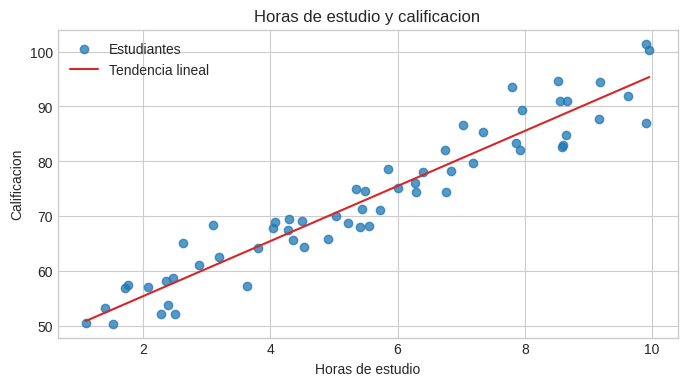

In [16]:
horas_estudio = rng.uniform(1, 10, size=60)
calificacion = 45 + 5.2 * horas_estudio + rng.normal(0, 4, size=60)
pendiente, intercepto = np.polyfit(horas_estudio, calificacion, 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(horas_estudio, calificacion, alpha=0.75, label="Estudiantes")
x_tendencia = np.linspace(horas_estudio.min(), horas_estudio.max(), 100)
ax.plot(x_tendencia, pendiente * x_tendencia + intercepto, color="tab:red", label="Tendencia lineal")
ax.set(title="Horas de estudio y calificacion", xlabel="Horas de estudio", ylabel="Calificacion")
ax.legend()
plt.show()

## 5. Boxplot

Resume la mediana, los cuartiles y los posibles valores atipicos.

/tmp/ipykernel_4088/2998252940.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=["Producto A", "Producto B", "Producto C"], patch_artist=True)


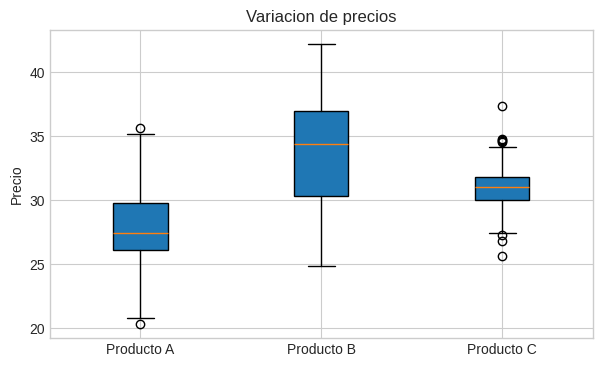

In [19]:
datos = [
    rng.normal(28, 3, 80),
    rng.normal(34, 4, 80),
    rng.normal(31, 2, 80),
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(datos, labels=["Producto A", "Producto B", "Producto C"], patch_artist=True)
ax.set(title="Variacion de precios", ylabel="Precio")
plt.show()

## 6. Varios graficos en una figura

Los subplots permiten comparar diferentes vistas de los mismos datos.

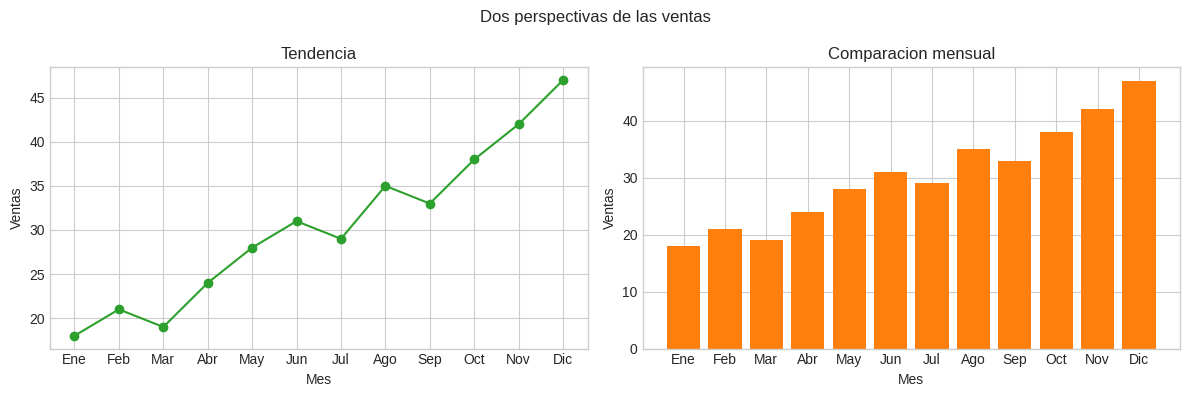

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["mes"], df["ventas"], marker="o", color="tab:green")
axes[0].set(title="Tendencia", xlabel="Mes", ylabel="Ventas")

axes[1].bar(df["mes"], df["ventas"], color="tab:orange")
axes[1].set(title="Comparacion mensual", xlabel="Mes", ylabel="Ventas")

fig.suptitle("Dos perspectivas de las ventas")
fig.tight_layout()
plt.show()

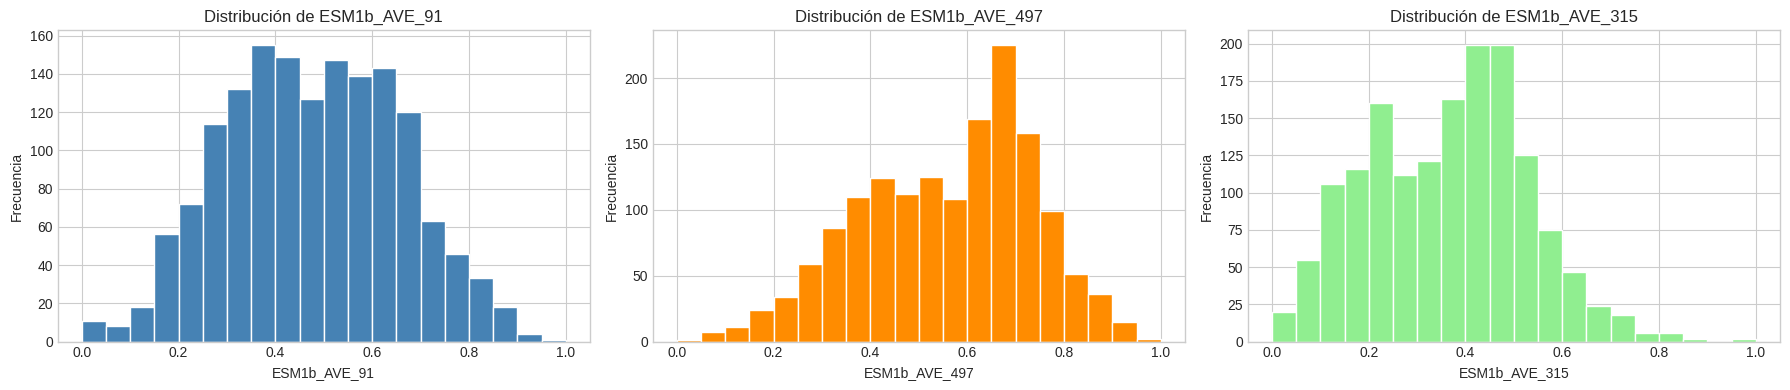

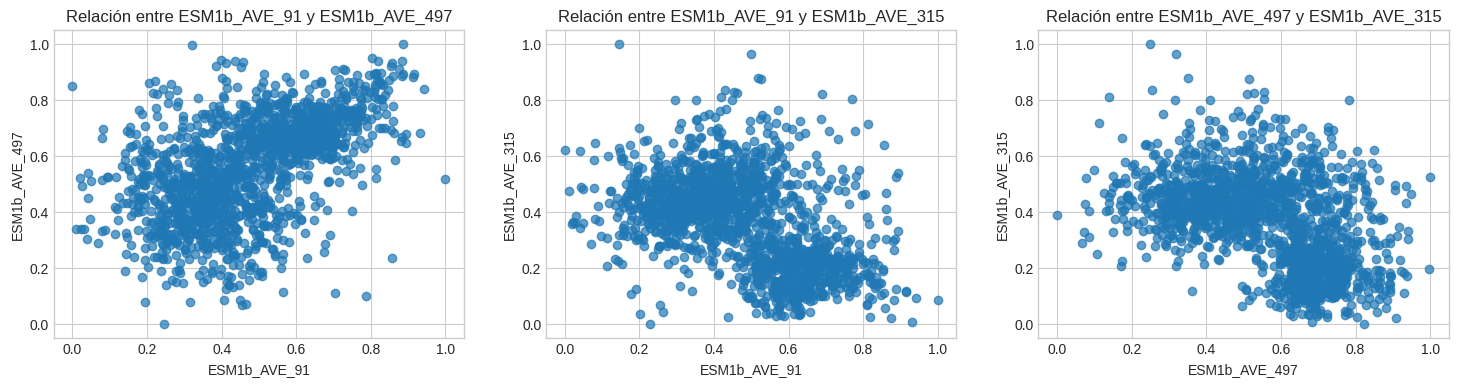

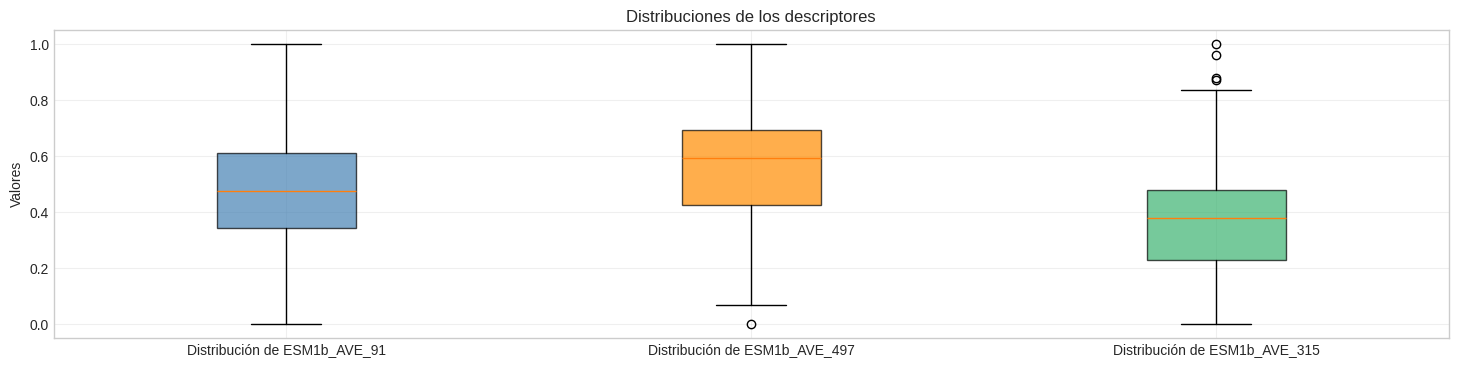

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/afp_pep.csv')
desc_1 = df.columns[0]
desc_2 = df.columns[1]
desc_3 = df.columns[2]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(df[desc_1].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title(f'Distribución de {desc_1}')
axes[0].set_xlabel(desc_1)
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df[desc_2].dropna(), bins=20, color='darkorange', edgecolor='white')
axes[1].set_title(f'Distribución de {desc_2}')
axes[1].set_xlabel(desc_2)
axes[1].set_ylabel('Frecuencia')

axes[2].hist(df[desc_3].dropna(), bins=20, color='lightgreen', edgecolor='white')
axes[2].set_title(f'Distribución de {desc_3}')
axes[2].set_xlabel(desc_3)
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].scatter(df[desc_1], df[desc_2], alpha=0.7)
axes[0].set_title(f'Relación entre {desc_1} y {desc_2}')
axes[0].set_xlabel(desc_1)
axes[0].set_ylabel(desc_2)

axes[1].scatter(df[desc_1], df[desc_3], alpha=0.7)
axes[1].set_title(f'Relación entre {desc_1} y {desc_3}')
axes[1].set_xlabel(desc_1)
axes[1].set_ylabel(desc_3)

axes[2].scatter(df[desc_2], df[desc_3], alpha=0.7)
axes[2].set_title(f'Relación entre {desc_2} y {desc_3}')
axes[2].set_xlabel(desc_2)
axes[2].set_ylabel(desc_3)
plt.show()

# agregame una figura con cajas y bigotes de las 3 distribuciones de los 3 descriptores, 
# con etiquetas y colores diferentes para cada caja, no hagas 3 diferenbtes graficas,
# pon los tres en la misma figura, con un tamaño de figura de 18x4, y con un título para
# cada caja que diga "Distribución de {descriptor}", y un título general para la figura 
# que diga "Distribuciones de los descriptores".

fig, ax = plt.subplots(figsize=(18, 4))
ax.grid(True, alpha=0.3)

boxplot = ax.boxplot(
    [
        df[desc_1].dropna(),
        df[desc_2].dropna(),
        df[desc_3].dropna()
    ],
    tick_labels=[
        f'Distribución de {desc_1}',
        f'Distribución de {desc_2}',
        f'Distribución de {desc_3}'
    ],
    patch_artist=True
)

colores = ['steelblue', 'darkorange', 'mediumseagreen']

for caja, color in zip(boxplot['boxes'], colores):
    caja.set_facecolor(color)
    caja.set_alpha(0.7)

ax.set_title('Distribuciones de los descriptores')
ax.set_ylabel('Valores')
plt.show()



In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


datos = pd.read_csv('/content/afp_pep.csv')
desc_1 = datos.columns[0]
desc_2 = datos.columns[1]
desc_3 = datos.columns[2]

# Crear los 3 clusters
modelo = KMeans(n_clusters=3, random_state=42, n_init=10)
datos["cluster"] = modelo.fit_predict(X)

print(datos["cluster"].value_counts().sort_index())
display(datos.head())

# Visualización tridimensional
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for cluster in sorted(datos["cluster"].unique()):
    seleccion = datos["cluster"] == cluster
    ax.scatter(
        datos.loc[seleccion, "grupo3"],
        datos.loc[seleccion, "horas_estudio"],
        datos.loc[seleccion, "notas"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

ax.set_xlabel("Grupo 3")
ax.set_ylabel("Horas de estudio")
ax.set_zlabel("Notas")
ax.set_title("Análisis de clusters con K-Means (k=3)")
ax.legend()
plt.show()